In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import optuna 
from scipy import stats
import missingno as msno
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
import statsmodels.api as sm
from sklearn.model_selection import learning_curve
from sklearn.metrics import roc_curve, precision_recall_curve, auc, precision_score, recall_score, f1_score, roc_auc_score
import optuna
#from utils.perm_class import ClassificationCV
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
import shap
from PyALE import ale

Initialize

In [2]:
df = pd.read_csv('..\Data\loan_data_sample.csv')
features = ['loan_amnt', 'term', 'emp_length', 'home_ownership',
       'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record',
       'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'mths_since_last_major_derog',
       'application_type', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m',
       'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il',
       'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc',
       'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'chargeoff_within_12_mths', 'mo_sin_old_il_acct',
       'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl',
       'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq',
       'mths_since_recent_inq', 'mths_since_recent_revol_delinq',
       'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl',
       'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl',
       'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m',
       'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
       'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies',
       'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit',
       'months_sincefrst_credit', 'public_record', 'is_consolidation',
       'addr_state', 'is_currently_delinq', 'has_il_history']

index_sql = 'Loan_ID'
target = 'predictor'

df_features  = df[features]
df_predictor = pd.Series(df[target])


#Imputing col's we imputed with 999 in SQL
imputed_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_last_major_derog', 'mths_since_recent_bc_dlq', 
    'mths_since_recent_inq', 'mths_since_recent_revol_delinq'
]

df_features.loc[:,imputed_cols] = df_features[imputed_cols].replace(999.0, np.nan)





X_train, X_test, y_train,y_test = train_test_split(df_features,df_predictor,stratify=df_predictor,test_size=.2,random_state=11)

categorical_features = X_train.select_dtypes(include=['object','category']).columns.tolist()
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()

Pipeline for Flags / missing values  --- Target Encoding

In [3]:
from sklearn import set_config


categorical_features = ['home_ownership', 'verification_status', 'application_type', 'addr_state']

X_temp_data = X_train.copy()
X_temp_data['predictor'] = y_train
state_means = X_temp_data.groupby('addr_state')['predictor'].mean()
global_default_mean = y_train.mean()

m= 10 #smoothing parameter
state_means = X_temp_data.groupby('addr_state')['predictor'].mean()
state_counts = X_temp_data['addr_state'].value_counts()
means_smoothed = ((state_counts*state_means)+(m*global_default_mean))/(state_counts+m)

X_train['state_enc'] = X_train['addr_state'].map(means_smoothed)
X_test['state_enc'] = X_test['addr_state'].map(means_smoothed)
X_test['state_enc'] = X_test['state_enc'].fillna(global_default_mean)
categorical_features.remove('addr_state')

X_encoded=pd.get_dummies(X_train[categorical_features],drop_first=True,sparse=False,dtype=int)
X_train = pd.concat([X_train[numerical_features],X_encoded],axis=1)

X_encoded_test = pd.get_dummies(X_test[categorical_features],drop_first=True,sparse=False,dtype=int)
X_test = pd.concat([X_test[numerical_features],X_encoded_test],axis=1)
#align columns
X_test = X_test.reindex(columns=X_train.columns,fill_value=0)




'''Pipeline for NaN's/ flags'''

zero_cols = [
    'max_bal_bc', 'all_util', 'il_util', 'open_acc_6m', 
    'open_il_12m', 'open_il_24m', 'open_rv_12m', 'open_rv_24m', 'inq_last_12m',
    'open_act_il', 'total_bal_il', 'total_il_high_credit_limit', 'is_consolidation'
]

flag_cols = [
    'mths_since_last_delinq', 'mths_since_last_record', 
    'mths_since_recent_bc_dlq', 'mths_since_recent_revol_delinq', 
    'mths_since_recent_inq', 'mths_since_rcnt_il',
    'mths_since_last_major_derog'
]

median_cols = [
    'months_sincefrst_credit', 'annual_inc', 'inq_last_6mths', 
    'revol_util', 'total_acc', 'pub_rec', 'open_acc', 
    'mo_sin_old_rev_tl_op', 'num_rev_accts', 'tot_hi_cred_lim',
    'acc_open_past_24mths', 'num_bc_sats', 'num_sats', 'mort_acc',
    'mths_since_recent_bc', 'total_bc_limit', 'pub_rec_bankruptcies',
    'total_rev_hi_lim', 'inq_fi', 'avg_cur_bal', 'bc_open_to_buy', 
    'bc_util', 'mo_sin_old_il_acct', 'mo_sin_rcnt_rev_tl_op', 
    'mo_sin_rcnt_tl', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 
    'num_actv_rev_tl', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 
    'num_rev_tl_bal_gt_0', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 
    'pct_tl_nvr_dlq', 'percent_bc_gt_75',
    'total_cu_tl', 'total_bal_ex_mort', 'num_tl_30dpd', 'num_tl_120dpd_2m', 'chargeoff_within_12_mths'
]

set_config(transform_output="pandas")

preprocessing = ColumnTransformer([
    ('zeros',SimpleImputer(strategy='constant',fill_value=0),zero_cols),
    ('flags',SimpleImputer(strategy= 'median',add_indicator=True),flag_cols),
    ('median',SimpleImputer(strategy='median'),median_cols)
],remainder='passthrough')

X_train = preprocessing.fit_transform(X_train)
X_test = preprocessing.transform(X_test)





"""Feature Engineering"""

eps = 0.001 # to avoid dividing by zero
# 1. Loan-to-Income
X_train['FE_loan_to_income'] = X_train['remainder__loan_amnt'] / (X_train['median__annual_inc'] + eps)
X_test['FE_loan_to_income'] = X_test['remainder__loan_amnt'] / (X_test['median__annual_inc'] + eps)

# 2. Monthly Free Cash Flow
X_train['FE_free_cash_flow'] = (X_train['median__annual_inc'] / 12) * (1 - (X_train['remainder__dti'] / 100))
X_test['FE_free_cash_flow'] = (X_test['median__annual_inc'] / 12) * (1 - (X_test['remainder__dti'] / 100))

# 3. Credit Line Activity Ratio
X_train['FE_activity_ratio'] = X_train['median__num_actv_rev_tl'] / (X_train['median__num_op_rev_tl'] + eps)
X_test['FE_activity_ratio'] = X_test['median__num_actv_rev_tl'] / (X_test['median__num_op_rev_tl'] + eps)

Winsorize

In [4]:
upperbounds = X_train.quantile(0.99)
lowerbounds = X_train.quantile(.01)

X_train = X_train.clip(lower=lowerbounds,upper=upperbounds,axis=1)
X_test = X_test.clip(lower=lowerbounds,upper=upperbounds,axis=1)

Trying base models

In [ ]:
models = {
    'XGboost': XGBClassifier(random_state=11),
    'Light':LGBMClassifier(random_state=11,verbose=-1),
    'catboost': CatBoostClassifier(random_state=11,eval_metric='AUC')
}

cv = StratifiedKFold(n_splits=3,shuffle=True,random_state=11)

results= []

for name, model in models.items():

    scores = cross_val_score(
        model,X_train,y_train,cv=cv,
        scoring='roc_auc',n_jobs=-1
    )

    results.append({
        'Model': name,
        'Mean_AUC': scores.mean(),
        'Std_Auc': scores.std(),
        'Min_Auc': scores.min(),
        'Max_Auc': scores.max()
        })

results_df = pd.DataFrame(results).sort_values(by='Mean_AUC',ascending=False).reset_index(drop=True)
print(results_df)



Hypertune our Catboost (Highest AUC) using optuna:

In [ ]:
def objective_cat(trial):
    # 1. Your excellent parameter ranges
    params = {
        "iterations": 1000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.5, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 50),
        "loss_function": "Logloss",
        "eval_metric": "AUC",          
        "random_seed": 11,              
        "verbose": 0,
    }

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=11)
    auc_scores = []

    #Manual loop allows us to use eval_set for early stopping
    for train_idx, val_idx in cv.split(X_train, y_train):
        X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
        X_val, y_val = X_train.iloc[val_idx], y_train.iloc[val_idx]

        model = CatBoostClassifier(**params)
        
        # Fit with the eval_set explicitly defined
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=50,
            verbose=0
        )

        # Predict probabilities for AUC
        preds = model.predict_proba(X_val)[:, 1]
        fold_auc = roc_auc_score(y_val, preds)
        auc_scores.append(fold_auc)

    return np.mean(auc_scores)


study_cat = optuna.create_study(direction="maximize")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_cat.optimize(objective_cat, n_trials=50, timeout=600)

print("Best AUC:", study_cat.best_value)
print("Best params:")
for k, v in study_cat.best_params.items():
    print(f"  {k}: {v}")

In [5]:
#best_params = study_cat.best_params
best_params = {
    'learning_rate': 0.027898809298734,
    'depth': 5,
    'l2_leaf_reg': 2.901699227197062,
    'subsample': 0.7921642564962083,
    'colsample_bylevel': 0.9276823462558479,
    'min_data_in_leaf': 50,
    "iterations": 1000,
    "loss_function": "Logloss",
    "eval_metric": "AUC"
}

                  

Learning Curve

In [ ]:
def plot_learning_curve(estimator,X,y,model_name='CatBoost'):
    train_sizes,train_scores,test_scores = learning_curve(
        estimator,X,y,cv=5,n_jobs=-1,
        train_sizes=np.linspace(0.1,1,10),
        scoring='roc_auc'
    )
    train_mean = np.mean(train_scores,axis=1)
    train_std = np.std(train_scores,axis=1)
    test_mean = np.mean(test_scores,axis=1)
    test_std = np.std(test_scores,axis=1)

    plt.plot(train_sizes,train_mean,label='Training Score',color='#d65f5f',marker='o')
    plt.fill_between(train_sizes,train_mean - train_std,train_mean+train_std,alpha=0.15,color='#d65f5f')

    plt.plot(train_sizes,test_mean,label='Cross Validation score',color='#4878d0', marker='o')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15, color='#4878d0')

    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel('Training Samples')
    plt.ylabel('AUC Score')
    plt.legend()
    plt.grid(True,linestyle='--', alpha=0.7)
    plt.savefig(f'LearningCurve_{model_name}.png',dpi=300,bbox_inches='tight')
    plt.show()


tuned_model = CatBoostClassifier(**best_params,verbose=0,random_state=11)


plot_learning_curve(tuned_model,X_train,y_train,model_name='CatBoost')

Dropped columns from SHAP

In [8]:
features_todrop=['zeros__open_rv_12m', 'flags__missingindicator_mths_since_last_delinq', 'median__num_sats']

X_train = X_train.drop(columns=features_todrop)
X_test = X_test.drop(columns=features_todrop)

Best Threshold

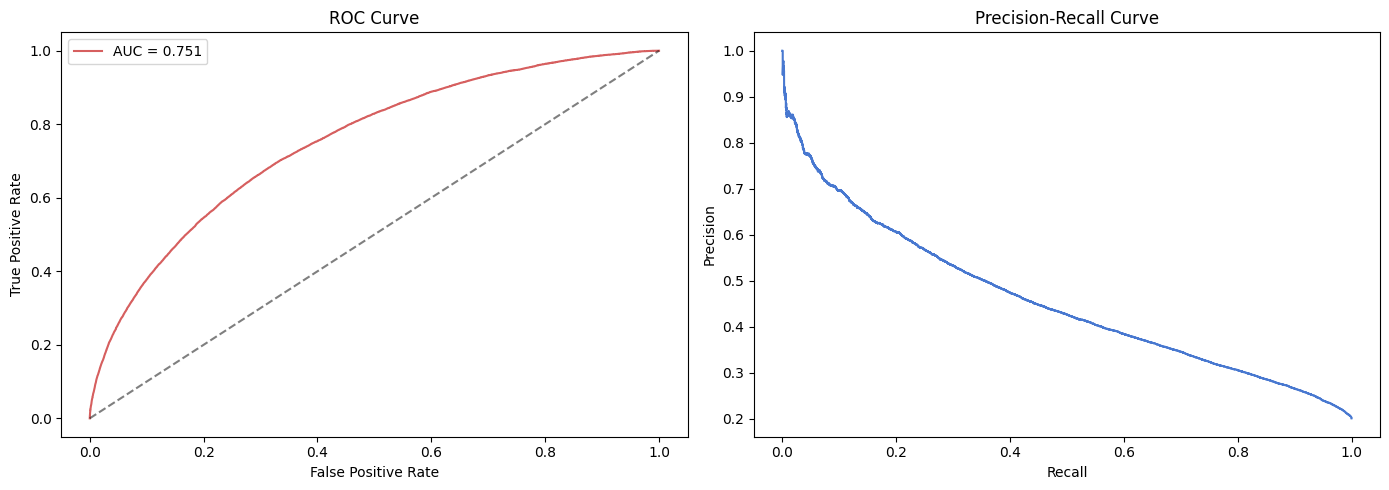

In [ ]:
tuned_model = CatBoostClassifier(**best_params,verbose=0,random_state=11)
tuned_model.fit(X_train,y_train)
y_pred_proba = tuned_model.predict_proba(X_train)[:, 1]

fpr, tpr, roc_thresholds = roc_curve(y_train, y_pred_proba)
roc_auc = auc(fpr, tpr)

precision, recall, pr_thresholds = precision_recall_curve(y_train, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#d65f5f', label=f'AUC = {roc_auc:.3f}')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

axes[1].plot(recall, precision, color='#4878d0')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

In [12]:
# F1 score at each threshold — balances precision and recall
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1])
best_threshold = pr_thresholds[np.argmax(f1_scores)]
print(f"Best threshold by F1: {best_threshold:.3f}")

Best threshold by F1: 0.239


In [17]:
thresholds_to_check = [0.2, 0.239, 0.3, 0.35, 0.4, 0.5]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print("-" * 48)

for t in thresholds_to_check:
    preds = (y_pred_proba >= t).astype(int)
    p = precision_score(y_train, preds)
    r = recall_score(y_train, preds)
    f = f1_score(y_train, preds)
    print(f"{t:<12.3f} {p:<12.3f} {r:<12.3f} {f:<12.3f}")

Threshold    Precision    Recall       F1          
------------------------------------------------
0.200        0.347        0.697        0.463       
0.239        0.390        0.589        0.469       
0.300        0.456        0.434        0.445       
0.350        0.514        0.329        0.402       
0.400        0.572        0.244        0.342       
0.500        0.684        0.113        0.193       


In [ ]:
avg_loan = X_train['remainder__loan_amnt'].mean()
loss_given_default = 0.6  # typically 60% of loan lost

for t in thresholds_to_check:
    preds = (y_pred_proba >= t).astype(int)
    fn = ((preds == 0) & (y_train == 1)).sum()
    fp = ((preds == 1) & (y_train == 0)).sum()
    expected_loss = (fn * avg_loan * loss_given_default) + (fp * avg_loan * 0.05)
    print(f"Threshold {t:.3f} | Expected Loss: ${expected_loss:,.0f}")

Threshold 0.200 | Expected Loss: $74,721,536
Threshold 0.239 | Expected Loss: $88,279,824
Threshold 0.300 | Expected Loss: $110,320,848
Threshold 0.350 | Expected Loss: $126,154,186
Threshold 0.400 | Expected Loss: $139,660,000
Threshold 0.500 | Expected Loss: $161,499,756


In [ ]:
avg_loan = X_train['remainder__loan_amnt'].mean()
avg_interest_rate =   # Got this from SQL, it would have been Data Leakage otherwise! :P
loss_given_default = 0.6
interest_revenue = avg_loan * avg_interest_rate  # revenue from good loans

print(f"Avg loan: ${avg_loan:,.0f}")
print(f"Avg interest rate: {avg_interest_rate:.3f}")
print(f"Estimated interest revenue per good loan: ${interest_revenue:,.0f}")

print(f"\n{'Threshold':<12} {'Expected Loss':<20} {'Expected Gain':<20} {'Net Value':<20}")
print("-" * 72)

for t in thresholds_to_check:
    preds = (y_pred_proba >= t).astype(int)
    
    tp = ((preds == 1) & (y_train_sample == 1)).sum()  # caught defaulters — avoided loss
    fp = ((preds == 1) & (y_train_sample == 0)).sum()  # wrongly rejected good borrowers — lost revenue
    tn = ((preds == 0) & (y_train_sample == 0)).sum()  # correctly approved — gained revenue
    fn = ((preds == 0) & (y_train_sample == 1)).sum()  # missed defaulters — took loss

    loss = (fn * avg_loan * loss_given_default) + (fp * interest_revenue)
    gain = (tn * interest_revenue) + (tp * avg_loan * loss_given_default)  # avoided losses count as gains
    net = gain - loss
    
    print(f"{t:<12.3f} ${loss:<19,.0f} ${gain:<19,.0f} ${net:<19,.0f}")

KeyError: 'remainder__int_rate'

SHAP
https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/tree_based_models/Catboost%20tutorial.html

In [ ]:
tuned_model = CatBoostClassifier(**best_params,verbose=0,random_state=11)
tuned_model.fit(X_train,y_train)
shp_explainer = shap.TreeExplainer(tuned_model)

#we'll take a sample of X_train

X_train_sample, null, y_train_sample, null1 = train_test_split(X_train,y_train,train_size=5000,
                                                               stratify=y_train,random_state=11)
 
shap_values = shp_explainer(X_train_sample)

In [ ]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_imprtnce_df = pd.DataFrame({
    'Feature':X_train_sample.columns,
    'Mean Absolute SHAP': mean_abs_shap
})

shap_imprtnce_df = shap_imprtnce_df.sort_values(by='Mean Absolute SHAP',ascending=False).reset_index(drop=True)
print(f' the Top 15 features are \n')
print(shap_imprtnce_df.head(15),'\n')
print(f'Bottom 30 features are \n')
print(shap_imprtnce_df.tail(30))
#features_todrop=shap_imprtnce_df[shap_imprtnce_df['Mean Absolute SHAP']< 0.005]['Feature'].tolist()
#print(features_todrop)
#We're going to take these features and drop them above


redo our shap with updated X_train

In [ ]:
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

slim_features =shap_imprtnce_df[shap_imprtnce_df['Mean Absolute SHAP']> 0.04]['Feature'].tolist()
X_train_slim = X_train[slim_features]
corr_matrix = X_train_slim.corr(method='spearman')


dist_matrix = 1 - np.abs(corr_matrix.values)

condensed_dist = squareform(dist_matrix, checks=False)

clustering = sch.linkage(condensed_dist, method="complete")

plt.figure(figsize=(14, 8))
plt.title("Feature Redundancy", fontsize=16)

dend = sch.dendrogram(
    clustering, 
    labels=X_train_slim.columns,
    leaf_rotation=90,
    leaf_font_size=10
)

plt.ylabel("Distance (1 - |Correlation|)", fontsize=12)
plt.axhline(y=0.2, color='r', linestyle='--') # 80% correlation
plt.tight_layout()
plt.show()

In [ ]:
#PAGE 123 Interpreting Machine learning with SHAP,
#since none fall under .2 I wont do it but would be a cool visual
# couldn't figure out how to redo it

shap plots

In [ ]:
plt.figure(figsize=(20, 14))
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title("Global Feature Impact (Top 15 Features)", fontsize=14)
plt.tight_layout()
#plt.savefig('Images_trees/Global_featureImpact.png',dpi=300,bbox_inches='tight')
plt.show()

PLotting out our TP/FP/TN/FN to see where our model was messing up / feature wise

In [ ]:
#plotting out true/false neg then true/false pos

y_pred_proba = tuned_model.predict_proba(X_train_sample)[:,1]
y_pred = (y_pred_proba >= 0.5).astype(int)
y_true = y_train_sample.values

tp = np.where((y_pred == 1) & (y_true ==1))[0]
fp = np.where((y_pred == 1) & (y_true == 0))[0]  
tn= np.where((y_pred == 0) & (y_true == 0))[0]  
fn=np.where((y_pred == 0) & (y_true == 1))[0]  

print(f"TP: {len(tp)}, FP: {len(fp)}, TN: {len(tn)}, FN: {len(fn)}")


In [ ]:

cases = {'True Positive': tp[0], 'False Positive': fp[0], 
         'True Negative': tn[0], 'False Negative': fn[0]}


for title, idx in cases.items():
    plt.figure(figsize=(12, 6))
    shap.plots.waterfall(shap_values[idx], max_display=10, show=False)
    plt.title(f"{title} | Actual: {y_true[idx]} | Pred prob: {y_pred_proba[idx]:.2f}", 
              fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
shap.plots.scatter(shap_values[:, "median__bc_util"])

In [ ]:
shap.dependence_plot("median__bc_util", shap_values.values, X_train_sample,
                     interaction_index="median__bc_open_to_buy")

ALE

In [ ]:
features=X_train_sample.columns
ale_eff = ale(
    X=X_train_sample[features],
    model=tuned_model,
    feature=['FE_loan_to_income'],
    grid_size=50,
    include_CI=True
)

weights -> plots

In [ ]:
refined_params_model= Pipeline([
    ('scaler', StandardScaler()),
    ('LinearR', LogisticRegression(C=0.18524697655221053,max_iter=1991,tol=0.005427682703976469,
                                   solver='saga',penalty='l1',random_state=11,class_weight='balanced'))
    ])

refined_params_model.fit(X_train,y_train)
model  = refined_params_model.named_steps['LinearR']
coefs = model.coef_[0]
odds_ratios = np.exp(coefs)


features=X_train.columns

model_results = pd.DataFrame({
    'Feature':features,
    'Coef':coefs,
    'odds':odds_ratios
})
mr = model_results.sort_values(by='odds').reset_index(drop=True)
print(mr)

Weight Plot

In [ ]:
plt.figure(figsize=(14,12))
colors = ['#d65f5f' if c>0 else '#4878d0' for c in mr['Coef']]

plt.barh(mr['Feature'], mr['Coef'],color=colors)
plt.axvline(x=0,color='black',linestyle='--',linewidth=2)
plt.title('LogisticRegression feature weights',fontsize=14,pad=15)
plt.xlabel('Impact on Default',fontsize=12)
plt.savefig('Images_log/LogisticRegression_feature_weight.png',dpi=300,bbox_inches='tight')

plt.tight_layout()
plt.show()



In [ ]:
mr_abs = mr.loc[:,['Feature','Coef','odds']]
mr_abs['abs Coef'] = mr_abs['Coef'].abs()
mr_abs=mr_abs.sort_values(by='abs Coef',ascending=False)
mr_abs=mr_abs.drop('Coef',axis=1)
print(mr_abs.head(10))

Effect plot

In [ ]:
params = {
    'C':90.31097151134563,
    'solver':'saga',
    'max_iter':1595,
    'tol':0.009993372798221852,
    'l1_ratio':0.6871072356705394
}

model = Pipeline([
        ('scaler', StandardScaler()),
        ('LinearR', LogisticRegression(**params, random_state=11,class_weight='balanced'))
    ])

model.fit(X_train,y_train)

#repeating because different columns before.
scaler = model.named_steps['scaler']
X_train_scaled = scaler.transform(X_train)
X_train_scaled_df = pd.DataFrame(X_train_scaled,columns=X_train.columns)
weights = model.named_steps['LinearR'].coef_[0]


effects_df = X_train_scaled_df * weights

means_abs_effects = effects_df.abs().mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))
sns.boxplot(
    data=effects_df,
    orient='h',
    palette='vlag',
    showfliers=False, #take out outliers
)

plt.axvline(x=0,color='red',linestyle='--',linewidth=1.5,alpha=0.7)
plt.title('Feature effects')
plt.xlabel('Effects on Log-Odds')
plt.grid(axis='x',linestyle='--',alpha=0.5)

#plt.savefig('Images_log/Logreg_effectplot.png',dpi=300,bbox_inches='tight')
plt.show()

Threshold analysis on X_train  → pick candidate thresholds
Expected loss on X_test         → validate which threshold actually performs best
                                  on unseen data before deploying


for the end